Ideas:
1. Simulated Anealing Approach?

In [4]:
!pip install shapely
!pip install matplotlib
!pip install numpy
!pip install pandas

In [5]:
import shapely
print(f'Using shapely {shapely.__version__}')

Using shapely 2.1.2


In [6]:
import math
import os
import random
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from shapely import affinity, touches
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.strtree import STRtree

pd.set_option('display.float_format', '{:.12f}'.format)

# Set precision for Decimal
getcontext().prec = 25
scale_factor = Decimal('1e15')

In [7]:
# Build the index of the submission, in the format:
#  <trees_in_problem>_<tree_index>

index = [f'{n:03d}_{t}' for n in range(1, 201) for t in range(n)]

In [8]:
def generate_weighted_angle():
    """
    Generates a random angle with a distribution weighted by abs(sin(2*angle)).
    This helps place more trees in corners, and makes the packing less round.
    """
    while True:
        angle = random.uniform(0, 2 * math.pi)
        if random.uniform(0, 1) < abs(math.sin(2 * angle)):
            return angle

In [9]:
class ChristmasTree:
    """Represents a single, rotatable Christmas tree of a fixed size."""

    def __init__(self, center_x='0', center_y='0', angle='0'):
        """Initializes the Christmas tree with a specific position and rotation."""
        self.center_x = Decimal(center_x)
        self.center_y = Decimal(center_y)
        self.angle = Decimal(angle)

        trunk_w = Decimal('0.15')
        trunk_h = Decimal('0.2')
        base_w = Decimal('0.7')
        mid_w = Decimal('0.4')
        top_w = Decimal('0.25')
        tip_y = Decimal('0.8')
        tier_1_y = Decimal('0.5')
        tier_2_y = Decimal('0.25')
        base_y = Decimal('0.0')
        trunk_bottom_y = -trunk_h

        initial_polygon = Polygon(
            [
                # Start at Tip
                (Decimal('0.0') * scale_factor, tip_y * scale_factor),
                # Right side - Top Tier
                (top_w / Decimal('2') * scale_factor, tier_1_y * scale_factor),
                (top_w / Decimal('4') * scale_factor, tier_1_y * scale_factor),
                # Right side - Middle Tier
                (mid_w / Decimal('2') * scale_factor, tier_2_y * scale_factor),
                (mid_w / Decimal('4') * scale_factor, tier_2_y * scale_factor),
                # Right side - Bottom Tier
                (base_w / Decimal('2') * scale_factor, base_y * scale_factor),
                # Right Trunk
                (trunk_w / Decimal('2') * scale_factor, base_y * scale_factor),
                (trunk_w / Decimal('2') * scale_factor, trunk_bottom_y * scale_factor),
                # Left Trunk
                (-(trunk_w / Decimal('2')) * scale_factor, trunk_bottom_y * scale_factor),
                (-(trunk_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Bottom Tier
                (-(base_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Middle Tier
                (-(mid_w / Decimal('4')) * scale_factor, tier_2_y * scale_factor),
                (-(mid_w / Decimal('2')) * scale_factor, tier_2_y * scale_factor),
                # Left side - Top Tier
                (-(top_w / Decimal('4')) * scale_factor, tier_1_y * scale_factor),
                (-(top_w / Decimal('2')) * scale_factor, tier_1_y * scale_factor),
            ]
        )
        rotated = affinity.rotate(initial_polygon, float(self.angle), origin=(0, 0))
        self.polygon = affinity.translate(rotated,
                                          xoff=float(self.center_x * scale_factor),
                                          yoff=float(self.center_y * scale_factor))

In [10]:
# Greedy Approach

def initialize_trees_greedy(num_trees, existing_trees=None):
    """
    This builds a simple, greedy starting configuration, by using the previous n-tree
    placements, and adding more tree for the (n+1)-tree configuration. We place a tree
    fairly far away at a (weighted) random angle, and the bring it closer to the center
    until it overlaps. Then we back it up until it no longer overlaps.

    You can easily modify this code to build each n-tree configuration completely
    from scratch.
    """

    # no trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # if start from the beginning with no trees, start from nothing. and if there is stuff to start from turn it into a list
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # how many trees need to place
    num_to_add = num_trees - len(placed_trees)

    if num_to_add > 0:
        # initialize the trees that need to be placed
        unplaced_trees = [
            ChristmasTree(angle=random.uniform(0, 360)) for _ in range(num_to_add)]
        # Only place the first tree at origin if starting from scratch
        if not placed_trees:  
            placed_trees.append(unplaced_trees.pop(0))

        for tree_to_place in unplaced_trees:
            # turn the trees that have been placed into polygons (lowk inefficient to be doing this everytime, change in my thing)
            placed_polygons = [p.polygon for p in placed_trees]
            # helps look for collisions
            tree_index = STRtree(placed_polygons)

            best_px = None
            best_py = None
            min_radius = Decimal('Infinity')

            # This loop tries 10 random starting attempts and keeps the best one
            for _ in range(10):
                # The new tree starts at a position 20 from the center, at a random vector angle.
                angle = generate_weighted_angle()
                vx = Decimal(str(math.cos(angle)))
                vy = Decimal(str(math.sin(angle)))

                # Move towards center along the vector in steps of 0.5 until collision
                radius = Decimal('20.0')
                step_in = Decimal('0.5')

                collision_found = False
                while radius >= 0:
                    # position to check
                    px = radius * vx
                    py = radius * vy
                    # creates the polygon to check
                    candidate_poly = affinity.translate(
                        tree_to_place.polygon,
                        xoff=float(px * scale_factor),
                        yoff=float(py * scale_factor))

                    # Looking for nearby objects
                    possible_indices = tree_index.query(candidate_poly)
                    # This is the collision detection step
                    if any((candidate_poly.intersects(placed_polygons[i]) and not
                            candidate_poly.touches(placed_polygons[i]))
                           for i in possible_indices):
                        collision_found = True
                        break
                    # step closer if no collision found
                    radius -= step_in

                # back up in steps of 0.05 until it no longer has a collision.
                if collision_found:
                    step_out = Decimal('0.05')
                    while True:
                        radius += step_out
                        px = radius * vx
                        py = radius * vy

                        candidate_poly = affinity.translate(
                            tree_to_place.polygon,
                            xoff=float(px * scale_factor),
                            yoff=float(py * scale_factor))

                        possible_indices = tree_index.query(candidate_poly)
                        if not any((candidate_poly.intersects(placed_polygons[i]) and not
                                   candidate_poly.touches(placed_polygons[i]))
                                   for i in possible_indices):
                            break
                # No collision found even at the center. Place it at the center.
                else:
                    radius = Decimal('0')
                    px = Decimal('0')
                    py = Decimal('0')
                # if the radius is better than the previous guesses/iterations, it's a better score so update
                if radius < min_radius:
                    min_radius = radius
                    best_px = px
                    best_py = py
            # update the tree to place's info based on the greedy search
            tree_to_place.center_x = best_px
            tree_to_place.center_y = best_py
            tree_to_place.polygon = affinity.translate(
                tree_to_place.polygon,
                xoff=float(tree_to_place.center_x * scale_factor),
                yoff=float(tree_to_place.center_y * scale_factor),
            )
            placed_trees.append(tree_to_place)  # Add the newly placed tree to the list
    # gets the polygons for all placed trees, including those which have been put down by the algo and gets the bounds
    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)
    # calculates the score of the frame based on the stigma
    score = side_length * side_length / num_trees

    return placed_trees, side_length, score

In [11]:
def plot_results(side_length, placed_trees, num_trees, score):
    """Plots the arrangement of trees and the bounding square."""
    _, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.viridis([i / num_trees for i in range(num_trees)])

    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    for i, tree in enumerate(placed_trees):
        # Rescale for plotting
        x_scaled, y_scaled = tree.polygon.exterior.xy
        x = [Decimal(val) / scale_factor for val in x_scaled]
        y = [Decimal(val) / scale_factor for val in y_scaled]
        ax.plot(x, y, color=colors[i])
        ax.fill(x, y, alpha=0.5, color=colors[i])

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny

    square_x = minx if width >= height else minx - (side_length - width) / 2
    square_y = miny if height >= width else miny - (side_length - height) / 2
    bounding_square = Rectangle(
        (float(square_x), float(square_y)),
        float(side_length),
        float(side_length),
        fill=False,
        edgecolor='red',
        linewidth=2,
        linestyle='--',
    )
    ax.add_patch(bounding_square)

    padding = 0.5
    ax.set_xlim(
        float(square_x - Decimal(str(padding))),
        float(square_x + side_length + Decimal(str(padding))))
    ax.set_ylim(float(square_y - Decimal(str(padding))),
                float(square_y + side_length + Decimal(str(padding))))
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    plt.title(f'{num_trees} Trees: {side_length:.12f} Score: {score: .12f}')
    plt.show()
    plt.close()

In [ ]:
# Simulated Annealing Approach
def checkPotentialTree(tree_to_place, placed_polygons):
    tree_index = STRtree(placed_polygons)
    # creates the polygon of the created
    candidate_poly = tree_to_place.polygon
    
    # Looking for nearby objects
    possible_indices = tree_index.query(candidate_poly)
    # This is the collision detection step
    if any((candidate_poly.intersects(placed_polygons[i]) and not
            candidate_poly.touches(placed_polygons[i]))
            for i in possible_indices):
        return Decimal('Infinity')
    # if there's no collision calculate a score
    else:
        placed_polygons.append(candidate_poly)
        # print("calculating bounds")
        bounds = unary_union(placed_polygons).bounds
        # print("done calculating bounds")
        minx = Decimal(bounds[0]) / scale_factor
        miny = Decimal(bounds[1]) / scale_factor
        maxx = Decimal(bounds[2]) / scale_factor
        maxy = Decimal(bounds[3]) / scale_factor

        width = maxx - minx
        height = maxy - miny
        # this forces a square bounding using the largest side
        side_length = max(width, height)

        # calculate potential score of each
        score = side_length * side_length / len(placed_polygons)
        # print('Adding {0} tree. Iteration {1}. px: {2}. py: {3}. pangle: {4}. Score: {5}. Best Score: {6}'.format(len(placed_polygons), i, px, py, pangle, score, best_score))
        placed_polygons.remove(candidate_poly)
        # no probability yet, kind of just gradient descent and just seeing what works. Just take if better
        return score
    
def initialize_trees_simulated_aneealing(num_trees, existing_trees=None):
    """
    Will be like DP where it relies on previous iterations and will use simulated annealing to place each new tree
    """
    # none trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # start from beginnning or create list of already placed trees
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # number of trees to place
    num_to_add = num_trees - len(placed_trees)
    for i in range(num_to_add):
        placed_polygons = [p.polygon for p in placed_trees]
        tree_index = STRtree(placed_polygons)
        
        best_score = Decimal('Infinity')

        # The new tree starts at a position 10 from the center, at a random vector angle. This is ok, random arbitray high temperature
        angle = generate_weighted_angle()
        x = Decimal(str(math.cos(angle))) * 20
        y = Decimal(str(math.sin(angle))) * 20
        angle = 0

        adjustPosition = not placed_trees
        nonCollidingLocation = False
        maxIterations = 200
        # need to change the loop, doesn't matter right now
        while(best_score == Decimal('Infinity')):
            for i in range(maxIterations):
                tree_to_place = ChristmasTree()
                temperature = 1 - i / maxIterations
                r = 5 * temperature
                angleR = 90 * temperature
                # get the random position for the thing to add
                px = x
                py = y
                pangle = angle
                if(adjustPosition):
                    # print("doing adjust position")
                    px = 0
                    py = 0
                    pangle = angle + Decimal(random.uniform(-90, 90))
                    # print(pangle)
                else:
                    # not really annealing, but for now I'm going to make it so that the more iterations we take, the smaller the range of movement
                    # selection = random.randint(1, 3)
                    # if(selection == 1):
                    #     px = x + Decimal(random.uniform(-r, r))
                    # elif(selection == 2):
                    #     py = y + Decimal(random.uniform(-r, r))
                    # else:
                    #     pangle = angle + Decimal(random.uniform(-angleR, angleR))
                    px = x + Decimal(random.uniform(-r, r))
                    py = y + Decimal(random.uniform(-r, r))
                    pangle = angle + Decimal(random.uniform(-angleR, angleR))
                
                tree_to_place.polygon = affinity.translate(
                tree_to_place.polygon,
                xoff=float(px * scale_factor),
                yoff=float(py * scale_factor),
                )
                tree_to_place.polygon = affinity.rotate(tree_to_place.polygon, float(pangle))
                score = checkPotentialTree(tree_to_place, placed_polygons)
                
                print("Score: {0}".format(score))
                if(score < best_score):
                    best_score = score
                    x = px
                    y = py
                    angle = pangle
                    print("Best Score Updated: {0}.".format(best_score))
        tree_to_place = ChristmasTree()
        tree_to_place.center_x = x
        tree_to_place.center_y = y
        tree_to_place.angle = angle
        tree_to_place.polygon = affinity.translate(
            tree_to_place.polygon,
            xoff=float(tree_to_place.center_x * scale_factor),
            yoff=float(tree_to_place.center_y * scale_factor),
        )
        tree_to_place.polygon = affinity.rotate(tree_to_place.polygon, float(angle))
        placed_trees.append(tree_to_place)  # Add the newly placed tree to the list

    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)

    # calculate potential score of each
    score = side_length * side_length / num_trees

    return placed_trees, side_length, score

Score: 0.8386960311342492710703040
Best Score Updated: 0.8386960311342492710703040. Angle: 61.66765817343284084017796
Score: 0.6777298885160970583110543
Best Score Updated: 0.6777298885160970583110543. Angle: 136.8936771717671376791259
Score: 1.005554836372202996285682
Score: 0.9235871079650062298032250
Score: 0.8916302245172006117197821
Score: 1.001218114181466324630900
Score: 0.9915301734356838881012869
Score: 0.8567307719583012969599726
Score: 0.8649560088370619012535796
Score: 1.002420643592786573150693
Score: 0.7136181453008116222617929
Score: 0.7349286991112661427702678
Score: 0.7227652550446627785199326
Score: 0.9252472530777418142360692
Score: 1.004045890469798968112422
Score: 0.8166481302826797414683530
Score: 0.8197625867209382374342837
Score: 1.003796599669585722821064
Score: 0.7990128376184686675340105
Score: 0.9659349668425373627813859
Score: 0.9802761650538002156390963
Score: 0.9994735524966559888644697
Score: 0.7351559179146945210573473
Score: 0.7489442563566613062407036

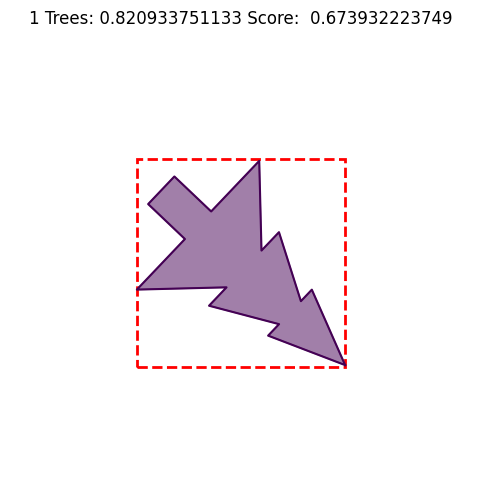

Score: 208.0444697245941895286714
Best Score Updated: 208.0444697245941895286714. Angle: 7.483199822172451831647777
Score: 246.0455527371790048910142
Score: 143.5468918413651535890487
Best Score Updated: 143.5468918413651535890487. Angle: -42.76527544657120216697876
Score: 200.4616000966216727938805
Score: 215.2905181311495044101083
Score: 207.0098834768529597541374
Score: 227.6094825858188798775231
Score: 77.1939387038721543430772
Best Score Updated: 77.1939387038721543430772. Angle: 41.06571738294106665989603
Score: 87.6457739749613283204187
Score: 60.8403463945751782808771
Best Score Updated: 60.8403463945751782808771. Angle: 46.28007954072659657640543
Score: 78.70985030341142219408565
Score: 67.50229274511702691605505
Score: 49.65344761446337624052686
Best Score Updated: 49.65344761446337624052686. Angle: -8.136718792101099495539526
Score: 64.37046256080565531037855
Score: 79.94380056582195660067645
Score: 26.82816914999135439493559
Best Score Updated: 26.82816914999135439493559. A

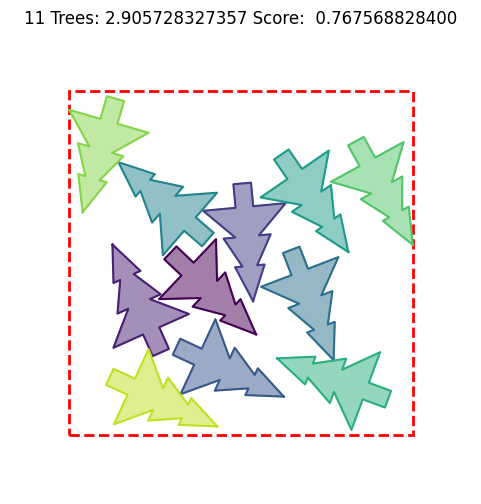

Score: 33.51314632626412038556986
Best Score Updated: 33.51314632626412038556986. Angle: -83.40562370293537242105231
Score: 35.4174222836785724055403
Score: 48.81266567355287010387554
Score: 21.67386141224476968255192
Best Score Updated: 21.67386141224476968255192. Angle: -113.9675811083474457063858
Score: 26.49252694900577151847115
Score: 19.68624765388983253641087
Best Score Updated: 19.68624765388983253641087. Angle: -160.4028903737127080830760
Score: 14.21172656063876138996197
Best Score Updated: 14.21172656063876138996197. Angle: -92.35721283842434559119284
Score: 22.32888312934495960261701
Score: 19.35400403303348303294292
Score: 9.176353475608758313451383
Best Score Updated: 9.176353475608758313451383. Angle: -34.05258847116409981481412
Score: 6.457017811072558490803031
Best Score Updated: 6.457017811072558490803031. Angle: -30.45041491551445744789818
Score: 14.15346055371590952714286
Score: 5.199098651515398176873287
Best Score Updated: 5.199098651515398176873287. Angle: -3.238

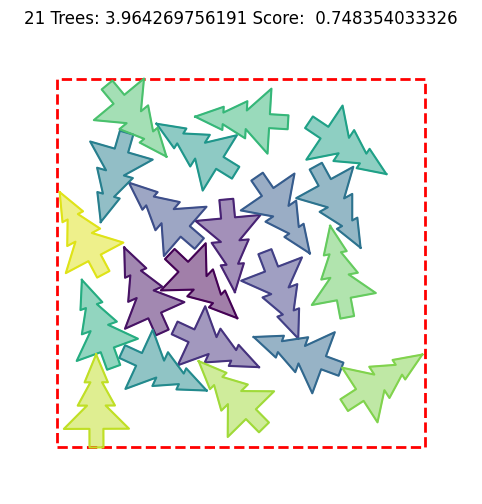

Score: 21.08715893659566478562540
Best Score Updated: 21.08715893659566478562540. Angle: -62.45213000407620995702018
Score: 17.20012595634426938025863
Best Score Updated: 17.20012595634426938025863. Angle: -80.20238883400142526625131
Score: 16.69838779125747445992912
Best Score Updated: 16.69838779125747445992912. Angle: -52.72502245798392550568678
Score: 17.55675269153545322182628
Score: 16.55408772629850887000797
Best Score Updated: 16.55408772629850887000797. Angle: -26.78519980569750202903378
Score: 21.21634805039454585368690
Score: 18.90535424893346142782088
Score: 19.63549599093795910406245
Score: 17.76911945763306503916080
Score: 24.07417367588065331857298
Score: 17.29658372965816443020703
Score: 17.12246399537359142928001
Score: 11.07534798933221021765484
Best Score Updated: 11.07534798933221021765484. Angle: -20.68276016989095467124570
Score: 18.2839831211965626422561
Score: 9.237973599954200092229914
Best Score Updated: 9.237973599954200092229914. Angle: 3.4629019425829881129

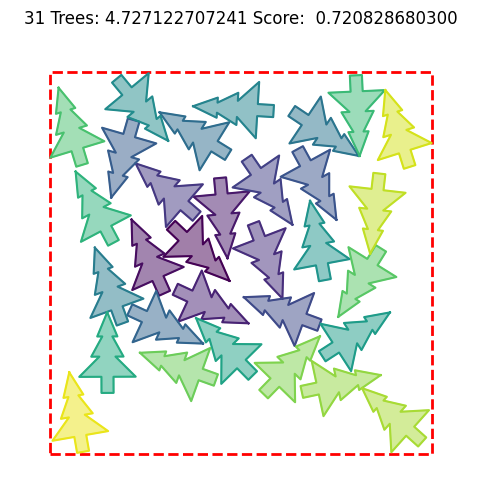

Score: 17.09186273963404333784878
Best Score Updated: 17.09186273963404333784878. Angle: -41.38042781414415571816789
Score: 20.29369489281698868229572
Score: 23.95377068757698960767335
Score: 15.67119224033820645226637
Best Score Updated: 15.67119224033820645226637. Angle: -119.8248996764612712695452
Score: 19.1215970133417517371709
Score: 19.98121149141188525775251
Score: 20.18704646815350923761761
Score: 18.55465097391132128060748
Score: 18.35705775111937648763294
Score: 13.78622377819804302076815
Best Score Updated: 13.78622377819804302076815. Angle: -54.00573893847300155357511
Score: 17.79885254923481268976506
Score: 13.11149869068046946251662
Best Score Updated: 13.11149869068046946251662. Angle: -102.8061369537777949290102
Score: 9.146016733429607606821869
Best Score Updated: 9.146016733429607606821869. Angle: -64.17365307593223633375594
Score: 10.85460999712537464306455
Score: 9.551300753220377143497866
Score: 11.63568162305983242279348
Score: 7.0822502873514765306643
Best Score

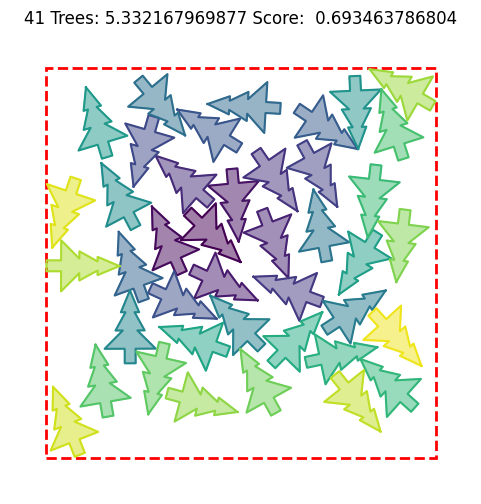

Score: 10.31253153028474787265113
Best Score Updated: 10.31253153028474787265113. Angle: 61.61990210967007897124859
Score: 10.52162807774532916808672
Score: 9.506117674042428368686217
Best Score Updated: 9.506117674042428368686217. Angle: 38.27869945644940230522480
Score: 8.657575873095580511014829
Best Score Updated: 8.657575873095580511014829. Angle: 117.2908920194149970939179
Score: 7.7030373644144682922477
Best Score Updated: 7.7030373644144682922477. Angle: 51.37982245234198330763318
Score: 8.041146614428814862135619
Score: 11.31726588518814184542486
Score: 8.315211034984816828623640
Score: 9.121267761161740755121114
Score: 10.32527934691621926794591
Score: 6.708704593114095538563005
Best Score Updated: 6.708704593114095538563005. Angle: 125.3121665608381647416536
Score: 6.577305532858951762508176
Best Score Updated: 6.577305532858951762508176. Angle: 74.08594379832550202991115
Score: 8.010247708853568416393040
Score: 7.720939018276185619845552
Score: 8.943122084993218069111960
Sc

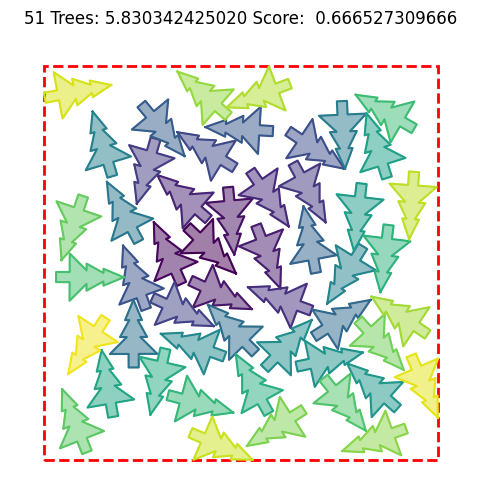

Score: 3.797607462314128870609423
Best Score Updated: 3.797607462314128870609423. Angle: -43.89778211217950598665993
Score: 2.358743115388166276539885
Best Score Updated: 2.358743115388166276539885. Angle: -115.1511430856590223470448
Score: 4.275165938819850447360021
Score: 1.911965468721668721404798
Best Score Updated: 1.911965468721668721404798. Angle: -58.84010777228176181097296
Score: 2.220422282649747792978952
Score: 0.9364932915218494341788819
Best Score Updated: 0.9364932915218494341788819. Angle: -107.1965008736138003087035
Score: 1.686264545009966554439698
Score: 0.9819902795537237882453794
Score: 1.212652067804770012324502
Score: 2.135452618954801175685423
Score: Infinity
Score: Infinity
Score: 1.379131437245012645176112
Score: 2.079204352329850641491937
Score: 2.016639502114208359406188
Score: 1.022377104500520198511883
Score: 1.732363201251063361691155
Score: Infinity
Score: 1.431401913885817602112051
Score: 1.679334250585024877026430
Score: 1.675736634620592412231500
Score

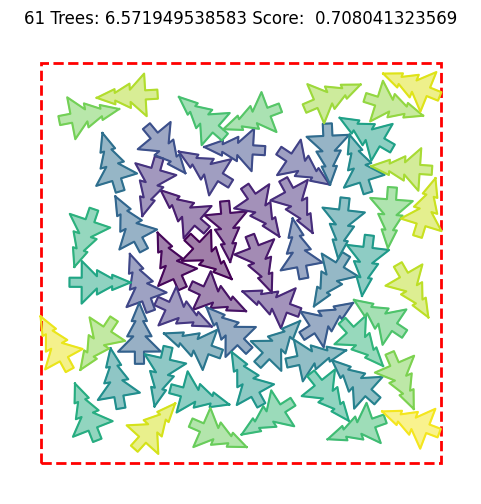

Score: 5.970954170885011433780121
Best Score Updated: 5.970954170885011433780121. Angle: 2.076709127741736438110820
Score: 6.744290163967662816829111
Score: 8.631793998887859681355676
Score: 4.901871906909312777973827
Best Score Updated: 4.901871906909312777973827. Angle: 13.45216913953480286636477
Score: 7.456208076444301157095526
Score: 3.528767090888335776583823
Best Score Updated: 3.528767090888335776583823. Angle: -67.77707385059483158329385
Score: 3.012288045666011966625984
Best Score Updated: 3.012288045666011966625984. Angle: -85.53481307593160920532682
Score: 1.816057996363168910237969
Best Score Updated: 1.816057996363168910237969. Angle: -9.466288061227132288877326
Score: 1.172952552841319686992671
Best Score Updated: 1.172952552841319686992671. Angle: 51.03547890180527701886604
Score: 1.953902658630961505527518
Score: 2.223996787907628373242821
Score: 2.031518158093448820364205
Score: 1.627242222345528837485808
Score: 2.243841523285802830248929
Score: 1.89207639152214226000

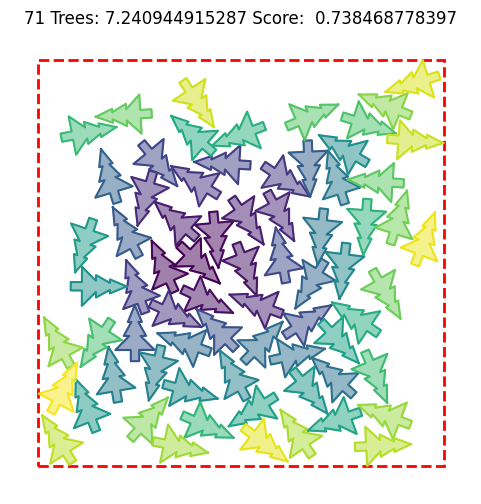

Score: 5.316231818398112533700071
Best Score Updated: 5.316231818398112533700071. Angle: -7.875114321747105350368656
Score: 6.040480232112270785618976
Score: 6.838989450143134203787890
Score: 3.012365640293753043582846
Best Score Updated: 3.012365640293753043582846. Angle: -30.55355185189112887655938
Score: 2.163601154033192502454768
Best Score Updated: 2.163601154033192502454768. Angle: 6.637606896580180659839241
Score: 2.405361574880580494398383
Score: 1.733432225603897296790317
Best Score Updated: 1.733432225603897296790317. Angle: 4.363078738507368825594310
Score: 0.8945759740728353153397079
Best Score Updated: 0.8945759740728353153397079. Angle: 40.58570371985607039277965
Score: 1.789360853365261606650892
Score: 1.572789252915249194631024
Score: 1.904538182912147999903258
Score: 0.7282122675863676783462215
Best Score Updated: 0.7282122675863676783462215. Angle: 75.33283999942597120025311
Score: 1.053532243789051195530938
Score: 0.9802738675965306096813003
Score: 1.7599756841731351

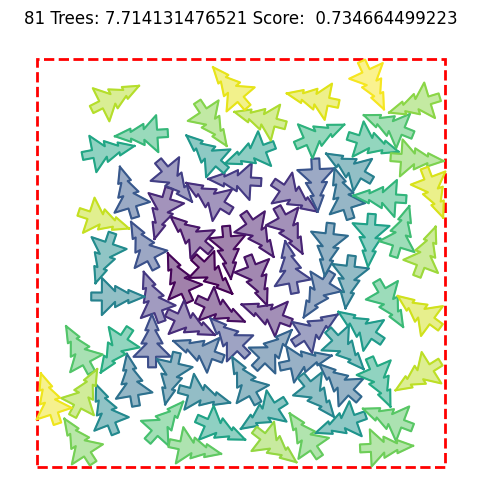

Score: 4.843464078867224997588848
Best Score Updated: 4.843464078867224997588848. Angle: 67.55174598893765391949273
Score: 3.969514201084982467745518
Best Score Updated: 3.969514201084982467745518. Angle: 79.83178475882692737286561
Score: 5.736738567443330767378617
Score: 4.995579076289200645032991
Score: 5.755577672725697986725046
Score: 5.045981765400875077646843
Score: 5.610623627265821790079751
Score: 5.971572474697212749532276
Score: 6.270549414078071632242668
Score: 5.600495683885742145555345
Score: 4.813539581997201060262676
Score: 5.979681474618066553751406
Score: 4.988656512695052549427459
Score: 4.156161573876412220613655
Score: 2.731426959947026592203576
Best Score Updated: 2.731426959947026592203576. Angle: 148.3404297975317263080797
Score: 1.799680583610392522112232
Best Score Updated: 1.799680583610392522112232. Angle: 126.7926632238328465973609
Score: Infinity
Score: 3.342187300069664502421398
Score: 2.246003412346413571530430
Score: 2.645685330393362531049211
Score: 2.4

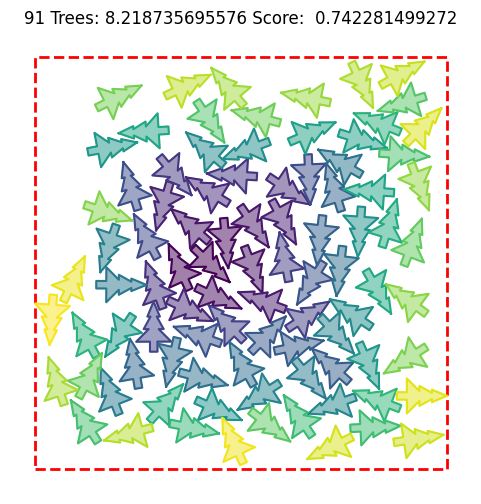

Score: 7.232418493713818701477984
Best Score Updated: 7.232418493713818701477984. Angle: 48.43876009585821407199546
Score: 4.788236107882161640601163
Best Score Updated: 4.788236107882161640601163. Angle: 68.90574349617973837212048
Score: 6.846982610307448311542603
Score: 3.600791126498428267583389
Best Score Updated: 3.600791126498428267583389. Angle: 88.93305614938709879879752
Score: 2.806912162663260637202701
Best Score Updated: 2.806912162663260637202701. Angle: 56.44994350771309399306119
Score: 4.107153573772471826246707
Score: 2.258317911922360754490690
Best Score Updated: 2.258317911922360754490690. Angle: 11.80765715507757818159007
Score: 3.217730334685071963575201
Score: 2.3794057686567841742815
Score: 1.071227436647582298300675
Best Score Updated: 1.071227436647582298300675. Angle: 18.89642810117391036328627
Score: 1.009431297447203693558846
Best Score Updated: 1.009431297447203693558846. Angle: 101.9317574180817018714151
Score: 0.8482246782311869068223890
Best Score Updated:

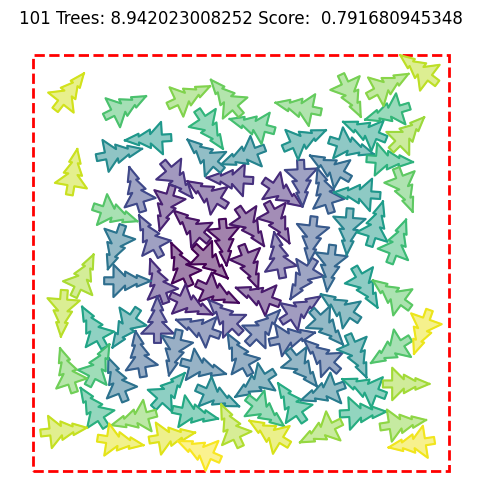

Score: 3.770752944429427167075186
Best Score Updated: 3.770752944429427167075186. Angle: -2.241806147601380416745087
Score: 4.523409114696140574075463
Score: 3.601211815070313542267871
Best Score Updated: 3.601211815070313542267871. Angle: 31.23217163595380441165617
Score: 4.423888474557161767845511
Score: 3.790422098285062838089957
Score: 2.798621937800164001828501
Best Score Updated: 2.798621937800164001828501. Angle: 17.03669532963677113457380
Score: 2.833284940111192348460057
Score: 3.988168911940413898097327
Score: 3.419271153725404489081219
Score: 2.330577378770402450828028
Best Score Updated: 2.330577378770402450828028. Angle: 0.8039430315753719469285072
Score: 2.890371941641360563926751
Score: 3.606504567836923710545330
Score: 2.420743754879466274738314
Score: 3.455460321177883395288894
Score: 3.681992324749353558360863
Score: 2.611305278051090395133329
Score: 2.848573416025498272605178
Score: 2.548905071210805693243474
Score: 2.824632236262195175163322
Score: 3.121860532312434

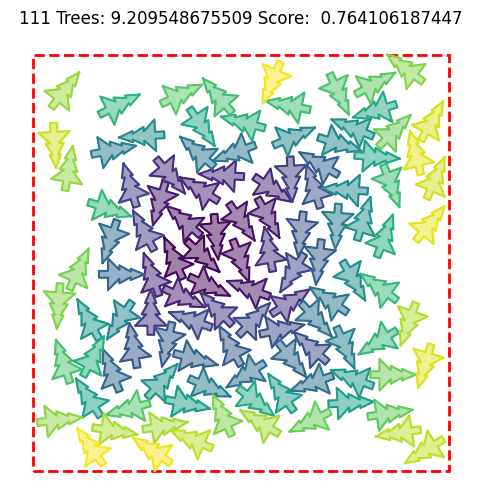

Score: 5.473549342426458487522554
Best Score Updated: 5.473549342426458487522554. Angle: -54.11966854261955006677454
Score: 5.115034941732649500787396
Best Score Updated: 5.115034941732649500787396. Angle: -134.9546627411956052355890
Score: 6.725379191214723952140585
Score: 3.978493678374134969636221
Best Score Updated: 3.978493678374134969636221. Angle: -77.50734816772551027952429
Score: 3.703210299697398163200381
Best Score Updated: 3.703210299697398163200381. Angle: -44.34671063548260860898151
Score: 5.007073948196200787768698
Score: 2.603028587594321492968625
Best Score Updated: 2.603028587594321492968625. Angle: -40.09056938097555189415286
Score: 2.199213250260054727696089
Best Score Updated: 2.199213250260054727696089. Angle: -59.32574119612164054160528
Score: 3.540804138851713498339354
Score: 3.131289938027136767664786
Score: 2.972106106160940759628565
Score: 1.561765420466312931760596
Best Score Updated: 1.561765420466312931760596. Angle: 4.251763328237970540612900
Score: 1.566

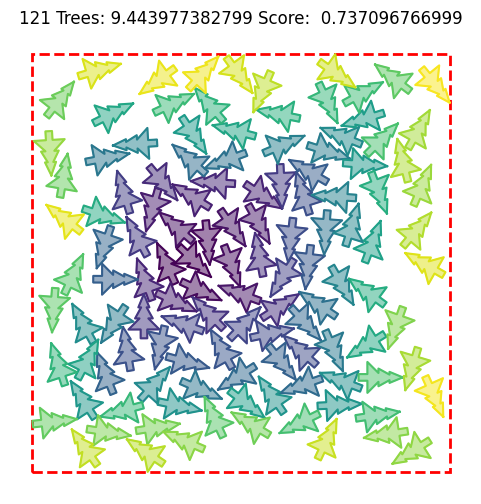

Score: 3.737293376300197744861519
Best Score Updated: 3.737293376300197744861519. Angle: -45.12475247787796206466737
Score: 4.586429559191605693309709
Score: 5.310274311099659502843942
Score: 2.923444641723665415317593
Best Score Updated: 2.923444641723665415317593. Angle: -130.4179313631793490912969
Score: 3.022739253775324688504072
Score: 2.611805200094877324206330
Best Score Updated: 2.611805200094877324206330. Angle: -54.72257711628182619278960
Score: 2.874964888687843674101749
Score: 2.839015651281214717216270
Score: 2.953591106434576232661326
Score: 2.772337244296241826838008
Score: 3.330602204649469671883151
Score: 4.095440951375127232513886
Score: 2.163385324097967097014494
Best Score Updated: 2.163385324097967097014494. Angle: -7.753624253832100521321996
Score: 2.867650579057384409801025
Score: 3.093189405513303272180111
Score: 2.907671319841736868857302
Score: 2.623877725901969557651916
Score: 2.740678907853417063678445
Score: 3.227375228560603600385989
Score: 2.0394413214082

In [ ]:
tree_data = []
current_placed_trees = []  # Initialize an empty list for the first iteration
total_score = 0
for n in range(200):
    # Pass the current_placed_trees to initialize_trees
    current_placed_trees, side, score = initialize_trees_simulated_aneealing(n+1, existing_trees=current_placed_trees)
    total_score = total_score + score
    if (n%10 == 0):
        plot_results(side, current_placed_trees, n+1, score)
    for tree in current_placed_trees:
        tree_data.append([tree.center_x, tree.center_y, tree.angle])
        
cols = ['x', 'y', 'deg']
submission = pd.DataFrame(
    index=index, columns=cols, data=tree_data).rename_axis('id')

for col in cols:
    submission[col] = submission[col].astype(float).round(decimals=6)
    
# To ensure everything is kept as a string, prepend an 's'
for col in submission.columns:
    submission[col] = 's' + submission[col].astype('string')
submission.to_csv('sample_submission.csv')

print(total_score)